In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
importlib.reload(julio)
import pandas as pd
import src.observables as obs
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
importlib.reload(ssh)

<module 'set_size_helper' from '/home/shankar/code/Spin1LongRangeOrder/python/figmaker/set_size_helper.py'>

In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)


In [3]:
idmrg_file = '../../data/iDMRG/scanChi800/corrs/results.h5'
df_i = read_corrs(idmrg_file)

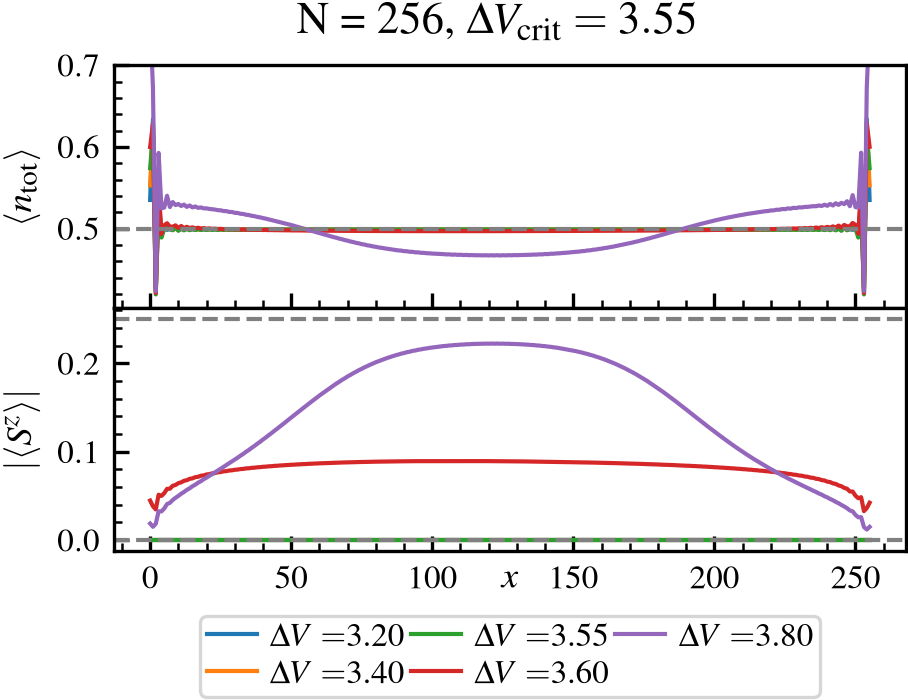

In [ ]:
fig, ax = plt.subplots(2, sharex=True, )
fig_dim = ssh.set_size_ht(fraction=0.5, subplots=(2,1))
fig.set_size_inches(fig_dim)
fig.subplots_adjust(hspace=0)
# ssh.align_x_axis(ax[0], ax[1])
dVvals = [3.2, 3.4, 3.55, 3.6, 3.8]

for nval in (256,):
    for j, dVval in enumerate(dVvals):
        col = f'C{j}'
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        ax[0].plot(seldf["ntot_expect"].values[0], c=col)
        ax[1].plot(np.abs(seldf["sz_expect"].values[0]), c=col, label=r'$\Delta V = $' + f'{dVval:.2f}')
ax[0].set_ylabel(r'$\langle n_{\mathrm{tot}}\rangle$')
ax[1].set_ylabel(r'$\abs{\langle S^z \rangle}$')
ax[1].set_xlabel(r'$x$', labelpad=-8)
ax[0].axhline(0.5, ls='--', c='gray')
ax[1].axhline(0.25, ls='--', c='gray')
ax[1].axhline(0.0, ls='--', c='gray')
ax[0].set_ylim(None, 0.7)

fig.suptitle(r"N = 256, $\Delta V_{\mathrm{crit}} = 3.55$")

handles, labels = ax[1].get_legend_handles_labels()
lgd = fig.legend(handles, labels, ncol=len(dVvals)//2 + 1, columnspacing=0.2, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(0.5, -0.6), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax[1].transAxes)

fig.savefig("figures/ShowPhaseSep.pdf", bbox_inches='tight')

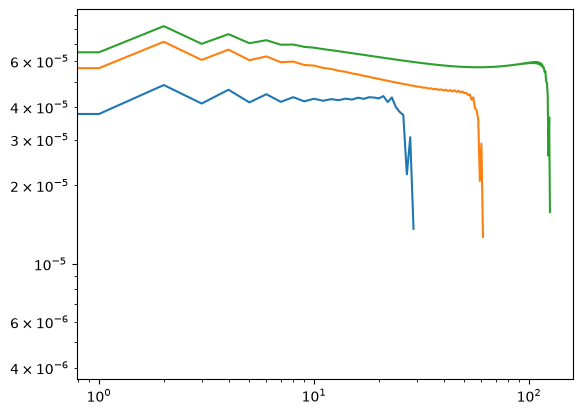

In [37]:
for nval in (64, 128, 256):
    seldf = julio.select_N_dv_from_df(nval, 3.7, df)
    plt.loglog(np.abs(seldf["spin2vec"].values[0]))
